# Conformal prediction para regressao

Conformal prediction transforma uma previsao pontual em um intervalo de predicao. A ideia e reservar uma parte dos dados para calibracao, observar os erros do modelo nessa parte e usar um quantil desses erros para montar os intervalos.

Para cobertura alvo de 90%, usamos `alpha = 0.10`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


In [2]:
pasta_do_script = os.getcwd()
caminho_dados = os.path.abspath(
    os.path.join(pasta_do_script, '..', 'WebScrapping', '202608_DadosDafiti_Combinados.csv')
)
df = pd.read_csv(caminho_dados)
df.head()

,Categoria,Marca,Cor,Vendedor,Produto,Tags,Preço Original,Preço Pix,Preço Parcelado,Quantidade de Parcelas
0,Feminino,adidas,Roxo,Jefferson Silva,Tênis SL 72 OG adidas Originals Roxo,"Calçados,Calçados Femininos,Tênis,Tênis Casual","R$ 699,99","R$ 489,99","R$ 489,99",5x
1,Feminino,adidas Originals,Bege,Jefferson Silva,TÊNIS HANDBALL SPEZIAL adidas Originals Bege,"Calçados,Calçados Femininos,Tênis,Tênis Casual","R$ 799,99","R$ 559,99","R$ 559,99",5x
2,Feminino,adidas,Vermelho,Jefferson Silva,TOKYO W adidas Originals Vermelho,"Calçados,Calçados Femininos,Tênis,Tênis Casual","R$ 599,99","R$ 419,99","R$ 419,99",5x
3,Feminino,Stessy Shoes,Off-white,Josefa Laudicea da Costa Ferracini,Scarpin Sapato Slingback Feminino Salto ...,"Calçados,Calçados Femininos,Scarpin","R$ 207,90","R$ 85,90","R$ 85,90",1x
4,Feminino,F G FLOR DE GRIFFE,Preto,LEONARDO FRANK DA SILVA,Mocassim Feminino Couro Legítimo Preto F...,"Calçados,Calçados Femininos,Mocassim","R$ 299,90","R$ 149,90","R$ 149,90",2x


In [3]:
# 1. Definimos as colunas que precisam ser tratadas
colunas_preco = ['Preço Original', 'Preço Pix', 'Preço Parcelado']

# 2. Loop para tratar cada coluna de preço
for col in colunas_preco:
    nova_coluna = f"{col} Numérico"
    
    # Fazemos a limpeza da string encadeando métodos do pandas
    df[nova_coluna] = (
        df[col]
        .astype(str)                           # Garante que tudo seja tratado como texto
        .str.replace('R$', '', regex=False)    # Remove o símbolo 'R$'
        .str.replace('.', '', regex=False)     # Remove o ponto de milhar (ex: 1.000,00 -> 1000,00)
        .str.replace(',', '.', regex=False)    # Troca a vírgula decimal por ponto (ex: 169,99 -> 169.99)
        .str.strip()                           # Remove espaços em branco nas pontas
    )
    
    # Converte a string tratada para float (erros='coerce' transforma valores inválidos/vazios em NaN)
    df[nova_coluna] = pd.to_numeric(df[nova_coluna], errors='coerce')

# 3. Cria a coluna de desconto (Original - Pix) usando as novas colunas numéricas
df['Desconto Pix'] = df['Preço Original Numérico'] - df['Preço Pix Numérico']

# Mostra o resultado para conferência
colunas_para_visualizar = [
    'Preço Original', 'Preço Original Numérico', 
    'Preço Pix', 'Preço Pix Numérico', 
    'Desconto Pix'
]
print(df[colunas_para_visualizar].head())

  Preço Original  Preço Original Numérico  Preço Pix  Preço Pix Numérico  \
0      R$ 699,99                   699.99  R$ 489,99              489.99   
1      R$ 799,99                   799.99  R$ 559,99              559.99   
2      R$ 599,99                   599.99  R$ 419,99              419.99   
3      R$ 207,90                   207.90   R$ 85,90               85.90   
4      R$ 299,90                   299.90  R$ 149,90              149.90   

   Desconto Pix  
0         210.0  
1         240.0  
2         180.0  
3         122.0  
4         150.0  


In [4]:
# 1. Primeiro, garantimos que não haja valores nulos (NaN) na coluna Tags, 
# substituindo-os por uma string vazia para não quebrar o código.
df['Tags'] = df['Tags'].fillna('')

# 2. Usamos o get_dummies separando pela vírgula. 
# Isso vai ler todas as tags, criar uma coluna para cada tag única e preencher com 0 ou 1.
colunas_tags = df['Tags'].str.get_dummies(sep=',')

# 3. (Opcional, mas recomendado) Adicionamos o prefixo 'Tag_' nas novas colunas.
# Isso evita confusão se alguma tag tiver o mesmo nome de uma coluna que já existe (ex: 'Cor')
colunas_tags = colunas_tags.add_prefix('Tag_')

# 4. Juntamos as novas colunas criadas ao nosso DataFrame original
df = pd.concat([df, colunas_tags], axis=1)

# Cria as variáveis binárias (0 e 1) para a quantidade de parcelas
# O Pandas vai criar colunas como "Quantidade de Parcelas_1x", "Quantidade de Parcelas_2x", etc.
df = pd.get_dummies(df, columns=['Quantidade de Parcelas'], dtype=int)

# Visualizando o resultado
print(f"Foram criadas {colunas_tags.shape[1]} novas colunas de tags!")


Foram criadas 64 novas colunas de tags!


In [5]:
print(df.columns.tolist())

['Categoria', 'Marca', 'Cor', 'Vendedor', 'Produto', 'Tags', 'Preço Original', 'Preço Pix', 'Preço Parcelado', 'Preço Original Numérico', 'Preço Pix Numérico', 'Preço Parcelado Numérico', 'Desconto Pix', 'Tag_Alpargatas', 'Tag_Anabela', 'Tag_Ankle Boot', 'Tag_Babuche', 'Tag_Bolsa Tiracolo e Baú', 'Tag_Bolsas', 'Tag_Bolsas e Acessórios', 'Tag_Bolsas e Acessórios Femininos', 'Tag_Bota', 'Tag_Bota Cano Curto', 'Tag_Bota Cano Médio', 'Tag_Bota Country e Franjas', 'Tag_Bota Cut Out Boot', 'Tag_Bota Montaria e Cano Longo', 'Tag_Bota Over Knee', 'Tag_Botas', 'Tag_Calçados', 'Tag_Calçados Femininos', 'Tag_Calçados Infantis', 'Tag_Calçados Masculinos', 'Tag_Chinelo', 'Tag_Chinelos', 'Tag_Chinelos e Sandálias', 'Tag_Coturno e Biker', 'Tag_Espadrille', 'Tag_Esporte', 'Tag_Esporte Feminino', 'Tag_Esporte Masculino', 'Tag_Galocha', 'Tag_Gladiadoras', 'Tag_Mocassim', 'Tag_Oxford', 'Tag_Pantufas', 'Tag_Papete', 'Tag_Peep Toe', 'Tag_Rasteirinhas', 'Tag_Sandália', 'Tag_Sandália Anabela', 'Tag_Sandália 

In [6]:
# 1. Pegamos os nomes de todas as colunas a partir da décima (índice 9 até o final)
colunas_selecionadas = df.columns[9:].tolist()

# 3. Filtramos o DataFrame original
df_modelo = df[colunas_selecionadas]

# Vendo o resultado (opcional, para conferir se deu certo)
print(f"Total de colunas selecionadas: {df_modelo.shape[1]}")
df_modelo.head()


Total de colunas selecionadas: 73


,Preço Original Numérico,Preço Pix Numérico,Preço Parcelado Numérico,Desconto Pix,Tag_Alpargatas,Tag_Anabela,Tag_Ankle Boot,Tag_Babuche,Tag_Bolsa Tiracolo e Baú,Tag_Bolsas,...,Tag_Tênis,Tag_Tênis Casual,Tag_Tênis Esportivo,Tag_Tênis Performance,Tag_Tênis performance,Quantidade de Parcelas_1x,Quantidade de Parcelas_2x,Quantidade de Parcelas_3x,Quantidade de Parcelas_4x,Quantidade de Parcelas_5x
0,699.99,489.99,489.99,210.0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,1
1,799.99,559.99,559.99,240.0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,1
2,599.99,419.99,419.99,180.0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,1
3,207.90,85.90,85.90,122.0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,299.90,149.90,149.90,150.0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [7]:
# Cria um DataFrame de qualidade mapeando nulos totais e o percentual
relatorio_qualidade = pd.DataFrame({
    'Valores Ausentes': df_modelo.isnull().sum(),
    'Percentual (%)': (df_modelo.isnull().sum() / len(df_modelo)) * 100
})

# Ordena da coluna com mais nulos para a com menos
relatorio_qualidade = relatorio_qualidade.sort_values(by='Valores Ausentes', ascending=False)

print(relatorio_qualidade)

                           Valores Ausentes  Percentual (%)
Preço Pix Numérico                     4831       29.215046
Desconto Pix                           4831       29.215046
Preço Original Numérico                   0        0.000000
Preço Parcelado Numérico                  0        0.000000
Tag_Alpargatas                            0        0.000000
...                                     ...             ...
Quantidade de Parcelas_1x                 0        0.000000
Quantidade de Parcelas_2x                 0        0.000000
Quantidade de Parcelas_3x                 0        0.000000
Quantidade de Parcelas_4x                 0        0.000000
Quantidade de Parcelas_5x                 0        0.000000

[73 rows x 2 columns]


In [8]:
# 1. Verifica o número de linhas antes da limpeza
linhas_antes = df_modelo.shape[0]
print(f"Total de linhas ANTES da limpeza: {linhas_antes}")

# 2. Exclui as linhas que contêm QUALQUER valor nulo
# Usamos uma nova variável para não perder os dados originais caso precise voltar atrás
df_modelo = df_modelo.dropna()

# Se você quisesse aplicar direto no df original, usaria:
# df.dropna(inplace=True)

# 3. Verifica o número de linhas depois da limpeza
linhas_depois = df_modelo.shape[0]
linhas_excluidas = linhas_antes - linhas_depois

print(f"Total de linhas DEPOIS da limpeza: {linhas_depois}")
print(f"Linhas excluídas: {linhas_excluidas}")

Total de linhas ANTES da limpeza: 16536
Total de linhas DEPOIS da limpeza: 11705
Linhas excluídas: 4831


In [9]:
# Vendo como ficou o novo DataFrame
print(df_modelo.shape)
df_modelo.head()

(11705, 73)


,Preço Original Numérico,Preço Pix Numérico,Preço Parcelado Numérico,Desconto Pix,Tag_Alpargatas,Tag_Anabela,Tag_Ankle Boot,Tag_Babuche,Tag_Bolsa Tiracolo e Baú,Tag_Bolsas,...,Tag_Tênis,Tag_Tênis Casual,Tag_Tênis Esportivo,Tag_Tênis Performance,Tag_Tênis performance,Quantidade de Parcelas_1x,Quantidade de Parcelas_2x,Quantidade de Parcelas_3x,Quantidade de Parcelas_4x,Quantidade de Parcelas_5x
0,699.99,489.99,489.99,210.0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,1
1,799.99,559.99,559.99,240.0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,1
2,599.99,419.99,419.99,180.0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,1
3,207.90,85.90,85.90,122.0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,299.90,149.90,149.90,150.0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [10]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel

# 1. O alpha de Conformal Prediction que você já tinha:
alvo = "Desconto Pix"
alpha = 0.10 

X = df_modelo.drop(columns=alvo)
y = df_modelo[alvo]

# ==========================================
# SELEÇÃO DE VARIÁVEIS COM LASSO
# ==========================================

# 2. Padroniza os dados (Coloca todas as colunas na mesma "régua")
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# 3. Treina o modelo Lasso. 
# Usamos o LassoCV porque ele testa sozinho qual é o melhor nível de punição/seleção
lasso = LassoCV(cv=5, random_state=42, n_jobs=-1)

# 4. Usamos o SelectFromModel para extrair apenas as variáveis que não foram zeradas
seletor = SelectFromModel(lasso)
seletor.fit(X_escalado, y)

# 5. Descobrindo quais colunas sobreviveram
colunas_mantidas = X.columns[seletor.get_support()]

# 6. Criando o novo X apenas com as variáveis importantes!
X_selecionado = X[colunas_mantidas]

# ==========================================
# RESULTADOS
# ==========================================
print(f"Total de variáveis ANTES do Lasso: {X.shape[1]}")
print(f"Total de variáveis DEPOIS do Lasso: {X_selecionado.shape[1]}")
print(f"Variáveis eliminadas: {X.shape[1] - X_selecionado.shape[1]}\n")

print("Exemplos de variáveis que foram mantidas:")
print(colunas_mantidas[:15].tolist()) # Mostra as 15 primeiras

Total de variáveis ANTES do Lasso: 72
Total de variáveis DEPOIS do Lasso: 2
Variáveis eliminadas: 70

Exemplos de variáveis que foram mantidas:
['Preço Original Numérico', 'Preço Pix Numérico']


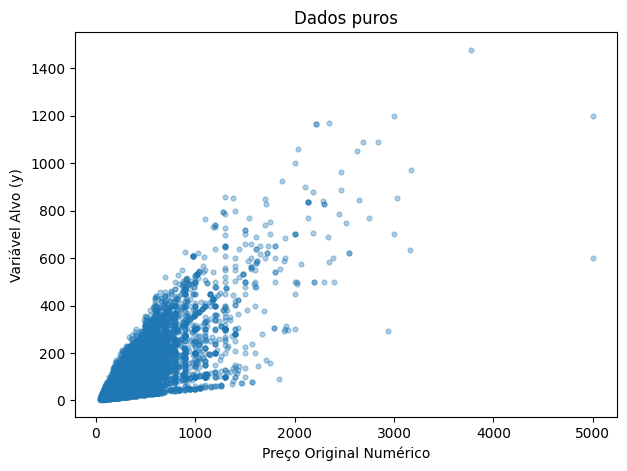

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(X['Preço Original Numérico'], y, s=12, alpha=0.35) 
plt.title("Dados puros")
plt.xlabel("Preço Original Numérico")
plt.ylabel("Variável Alvo (y)")
plt.show()

## Separando treino, calibracao e teste

O modelo aprende no treino. A calibracao fica separada para estimar o tamanho do erro. O teste fica para avaliar os intervalos no final.

In [12]:
X_treino_cal, X_teste, y_treino_cal, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_treino, X_cal, y_treino, y_cal = train_test_split(
    X_treino_cal, y_treino_cal, test_size=0.25, random_state=42
)

print("treino:", X_treino.shape)
print("calibracao:", X_cal.shape)
print("teste:", X_teste.shape)


treino: (7023, 72)
calibracao: (2341, 72)
teste: (2341, 72)


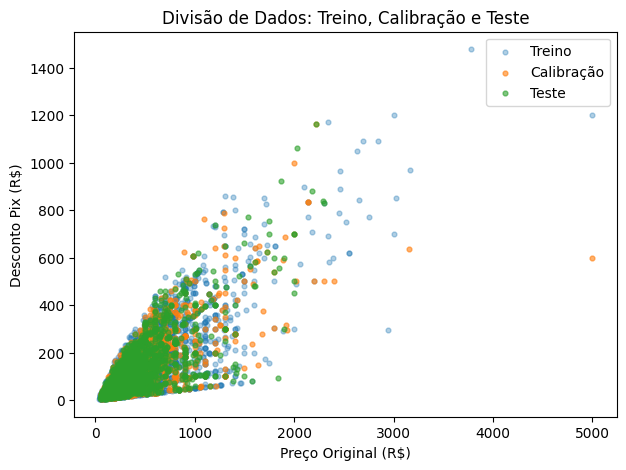

In [13]:
# Escolhemos uma coluna específica de X para o eixo horizontal
coluna_x = "Preço Original Numérico"

plt.figure(figsize=(7, 5))

# Plotamos cada conjunto selecionando apenas a coluna_x
plt.scatter(X_treino[coluna_x], y_treino, s=12, alpha=0.35, label="Treino")
plt.scatter(X_cal[coluna_x], y_cal, s=12, alpha=0.60, label="Calibração")
plt.scatter(X_teste[coluna_x], y_teste, s=12, alpha=0.60, label="Teste")

plt.title("Divisão de Dados: Treino, Calibração e Teste")
plt.xlabel("Preço Original (R$)")
plt.ylabel("Desconto Pix (R$)") # Seu y definido anteriormente
plt.legend()
plt.show()

## Split conformal comum

No split conformal comum, todos os pontos recebem a mesma largura de intervalo:

`previsao +- q`

O valor `q` e um quantil dos erros absolutos no conjunto de calibracao.

In [14]:
modelo = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42,
)

modelo.fit(X_treino, y_treino)

pred_cal = modelo.predict(X_cal)
erros_cal = np.abs(y_cal - pred_cal)

n_cal = len(erros_cal)
nivel_quantil = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
q = np.quantile(erros_cal, nivel_quantil, method="higher")

q

pred_teste = modelo.predict(X_teste)

baixo_comum = pred_teste - q
alto_comum = pred_teste + q

cobertura_comum = ((y_teste >= baixo_comum) & (y_teste <= alto_comum)).mean()
largura_comum = np.mean(alto_comum - baixo_comum)
mae_comum = mean_absolute_error(y_teste, pred_teste)

pd.Series({
    "cobertura": cobertura_comum,
    "largura_media": largura_comum,
    "mae": mae_comum,
    "q": q,
})


cobertura         0.908159
largura_media    11.469340
mae               3.442153
q                 5.734670
dtype: float64

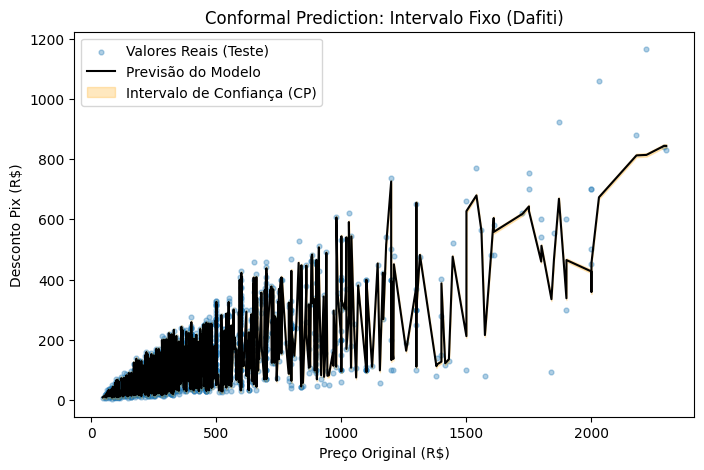

cobertura         0.908159
largura_media    11.469340
mae               3.442153
q                 5.734670
dtype: float64


In [15]:
# 1. Escolhemos a coluna para o eixo X
coluna_x = "Preço Original Numérico"

# 2. Descobrimos a ordem correta (crescente) baseada na coluna escolhida
ordem = np.argsort(X_teste[coluna_x].to_numpy())

# 3. Ordenamos todos os elementos do gráfico usando a 'ordem'
x_plot = X_teste[coluna_x].to_numpy()[ordem]
y_plot = y_teste.to_numpy()[ordem]
pred_plot = pred_teste[ordem]
baixo_plot = baixo_comum[ordem]
alto_plot = alto_comum[ordem]

# 4. Criamos o gráfico
plt.figure(figsize=(8, 5))

# Plota os pontos reais de teste
plt.scatter(x_plot, y_plot, s=12, alpha=0.35, label="Valores Reais (Teste)")

# Plota a linha da previsão do modelo
plt.plot(x_plot, pred_plot, color="black", label="Previsão do Modelo")

# Plota a faixa de incerteza (Conformal Prediction)
plt.fill_between(x_plot, baixo_plot, alto_plot, alpha=0.25, color="orange", label="Intervalo de Confiança (CP)")

plt.title("Conformal Prediction: Intervalo Fixo (Dafiti)")
plt.xlabel("Preço Original (R$)")
plt.ylabel("Desconto Pix (R$)")
plt.legend()
plt.show()

# (Opcional) Print dos seus resultados para fechar a célula
print(pd.Series({
    "cobertura": cobertura_comum,
    "largura_media": largura_comum,
    "mae": mae_comum,
    "q": q,
}))

## Split conformal com modelo de variancia

Agora a largura pode mudar de ponto para ponto. Usamos o conjunto de treino inteiro para treinar um modelo de media e, com os residuos desse modelo no proprio treino, treinamos outro modelo para prever o tamanho do erro.

Depois calibramos os erros normalizados:

`score = |y - previsao| / escala_prevista`

No teste, o intervalo fica:

`previsao +- q * escala_prevista`

In [16]:
modelo_media = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42,
)

modelo_media.fit(X_treino, y_treino)

pred_treino = modelo_media.predict(X_treino)
residuos = y_treino - pred_treino
variancia_observada = residuos ** 2

modelo_variancia = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)

modelo_variancia.fit(X_treino, variancia_observada)

pred_cal_adapt = modelo_media.predict(X_cal)
escala_cal = np.sqrt(modelo_variancia.predict(X_cal))

scores_cal = np.abs(y_cal - pred_cal_adapt) / escala_cal

n_cal = len(scores_cal)
nivel_quantil = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
q_adapt = np.quantile(scores_cal, nivel_quantil, method="higher")

q_adapt


np.float64(2.1367690493800233)

A diferença fundamental entre os dois modelos é **o que eles estão tentando adivinhar (prever)**. Enquanto o primeiro prevê o resultado real, o segundo prevê o tamanho do erro do primeiro.

Aqui está o detalhamento do papel de cada um:

**1. `modelo_media` (O Modelo Preditivo)**

* **O que ele aprende:** A relação entre as características do sapato (`X_treino`) e o desconto em Reais (`y_treino`).
* **O que ele prevê:** O valor esperado do Desconto Pix. Ele tenta cravar o número exato (a "média" dos resultados possíveis).
* **Analogia:** É o avaliador que diz: *"Acredito que este sapato terá R$ 30,00 de desconto"*.

**2. `modelo_variancia` (O Modelo de Incerteza)**

* **Como é treinado:** Após o primeiro modelo fazer suas previsões, calculamos onde ele errou (`residuos`) e elevamos ao quadrado (`variancia_observada = residuos ** 2`). O `modelo_variancia` é treinado para prever esses erros ao quadrado usando as mesmas características (`X_treino`).
* **O que ele prevê:** A "dúvida" ou margem de erro do primeiro modelo. Ele estima se o `modelo_media` vai acertar na mosca ou se vai errar feio para um determinado sapato.
* **Analogia:** É o supervisor que diz: *"Quando o sapato é uma bota cara, o avaliador costuma errar por uma margem de até R$ 15,00. Mas quando é uma sandália rasteira, ele erra no máximo por R$ 2,00"*.

---

**Por que precisamos dos dois juntos? (Conformal Prediction Adaptativo)**

No método tradicional (comum), você cria uma faixa de erro **fixa** (ex: R$ 10,00 para mais ou para menos) e aplica para todos os produtos da loja, ignorando que produtos mais caros ou de certas marcas são mais difíceis de prever.

Ao usar o `modelo_variancia`, você cria um multiplicador (`escala_cal` e `escala_teste`). Com isso, a sua margem de erro se torna **dinâmica**:

* Se o `modelo_variancia` diz que a previsão é **fácil** (baixa variância), a sua faixa de erro encolhe.
* Se o `modelo_variancia` diz que a previsão é **difícil** (alta variância), a sua faixa de erro alarga para garantir que o valor real ainda caia dentro do intervalo.

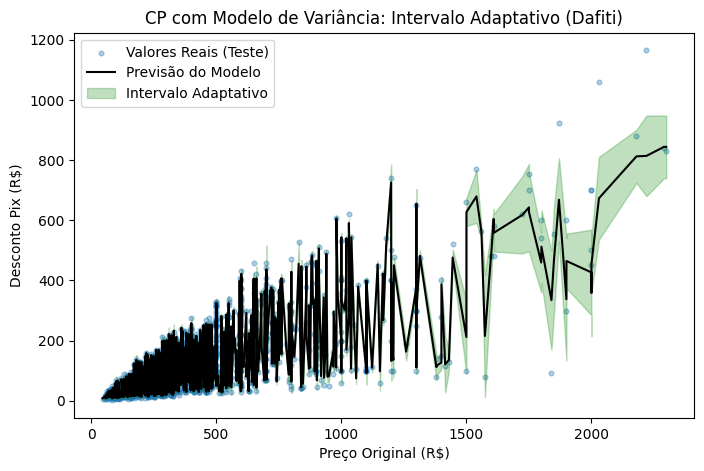

,método,cobertura,largura_media,mae,q
0,Intervalo Fixo (Comum),0.908159,11.469340,3.442153,5.734670
1,Intervalo Adaptativo (Variância),0.888936,10.344936,3.442153,2.136769


In [17]:
# 1. Previsões e definição da margem de erro na base de Teste
pred_teste_adapt = modelo_media.predict(X_teste)
# Aqui o modelo de variância estima o erro específico para cada linha de teste
escala_teste = np.sqrt(np.maximum(modelo_variancia.predict(X_teste), 0)) # np.maximum previne raízes negativas

# O limite agora é dinâmico: depende do q_adapt e da 'escala_teste' de cada produto
baixo_adapt = pred_teste_adapt - q_adapt * escala_teste
alto_adapt = pred_teste_adapt + q_adapt * escala_teste

# 2. Cálculo das métricas
cobertura_adapt = ((y_teste >= baixo_adapt) & (y_teste <= alto_adapt)).mean()
largura_adapt = np.mean(alto_adapt - baixo_adapt)
mae_adapt = mean_absolute_error(y_teste, pred_teste_adapt)

# 3. Preparação para o gráfico (Ordenando pelo Preço Original)
coluna_x = "Preço Original Numérico"
ordem = np.argsort(X_teste[coluna_x].to_numpy())

x_plot = X_teste[coluna_x].to_numpy()[ordem]
y_plot = y_teste.to_numpy()[ordem]
pred_plot_adapt = pred_teste_adapt[ordem]
baixo_plot_adapt = baixo_adapt[ordem]
alto_plot_adapt = alto_adapt[ordem]

# 4. Gráfico do Conformal Prediction Adaptativo
plt.figure(figsize=(8, 5))
plt.scatter(x_plot, y_plot, s=12, alpha=0.35, label="Valores Reais (Teste)")
plt.plot(x_plot, pred_plot_adapt, color="black", label="Previsão do Modelo")

# Faixa adaptativa (vai ficar mais fina onde o modelo tem certeza e mais larga onde tem dúvida)
plt.fill_between(x_plot, baixo_plot_adapt, alto_plot_adapt, alpha=0.25, color="green", label="Intervalo Adaptativo")

plt.title("CP com Modelo de Variância: Intervalo Adaptativo (Dafiti)")
plt.xlabel("Preço Original (R$)")
plt.ylabel("Desconto Pix (R$)")
plt.legend()
plt.show()

# 5. Tabela Comparativa (Fixo vs Adaptativo)
comparacao_dafiti = pd.DataFrame({
    "método": ["Intervalo Fixo (Comum)", "Intervalo Adaptativo (Variância)"],
    "cobertura": [cobertura_comum, cobertura_adapt],
    "largura_media": [largura_comum, largura_adapt],
    "mae": [mae_comum, mae_adapt],
    "q": [q, q_adapt],
})

# Exibe a tabela
comparacao_dafiti

In [18]:
pred_teste_adapt = modelo_media.predict(X_teste)
escala_teste = np.sqrt(modelo_variancia.predict(X_teste))

baixo_adapt = pred_teste_adapt - q_adapt * escala_teste
alto_adapt = pred_teste_adapt + q_adapt * escala_teste

cobertura_adapt = ((y_teste >= baixo_adapt) & (y_teste <= alto_adapt)).mean()
largura_adapt = np.mean(alto_adapt - baixo_adapt)
mae_adapt = mean_absolute_error(y_teste, pred_teste_adapt)

comparacao = pd.DataFrame({
    "metodo": ["split comum", "com modelo de variancia"],
    "cobertura": [cobertura_comum, cobertura_adapt],
    "largura_media": [largura_comum, largura_adapt],
    "mae": [mae_comum, mae_adapt],
    "q": [q, q_adapt],
})

comparacao


,metodo,cobertura,largura_media,mae,q
0,split comum,0.908159,11.469340,3.442153,5.734670
1,com modelo de variancia,0.888936,10.344936,3.442153,2.136769


## Intervalos no teste

No metodo comum, a largura e fixa. No metodo com variancia, a largura muda conforme a escala prevista para cada ponto.

In [19]:
intervalos = pd.DataFrame({
    "y_real": y_teste,
    "pred_comum": pred_teste,
    "baixo_comum": baixo_comum,
    "alto_comum": alto_comum,
    "pred_variancia": pred_teste_adapt,
    "baixo_variancia": baixo_adapt,
    "alto_variancia": alto_adapt,
})

intervalos.head(10).round(2)


,y_real,pred_comum,baixo_comum,alto_comum,pred_variancia,baixo_variancia,alto_variancia
12711,247.00,247.36,241.62,253.09,247.36,240.10,254.61
8581,31.00,28.29,22.56,34.02,28.29,25.38,31.20
3418,51.59,51.83,46.10,57.56,51.83,51.07,52.59
12728,320.00,323.11,317.37,328.84,323.11,317.14,329.08
15672,60.00,55.55,49.81,61.28,55.55,48.77,62.32
3554,30.00,30.09,24.36,35.83,30.09,29.00,31.18
13414,9.00,9.42,3.68,15.15,9.42,7.49,11.35
6805,74.99,73.88,68.15,79.62,73.88,71.82,75.94
11879,374.94,374.36,368.62,380.09,374.36,363.07,385.65
14083,120.00,119.83,114.09,125.56,119.83,116.84,122.81


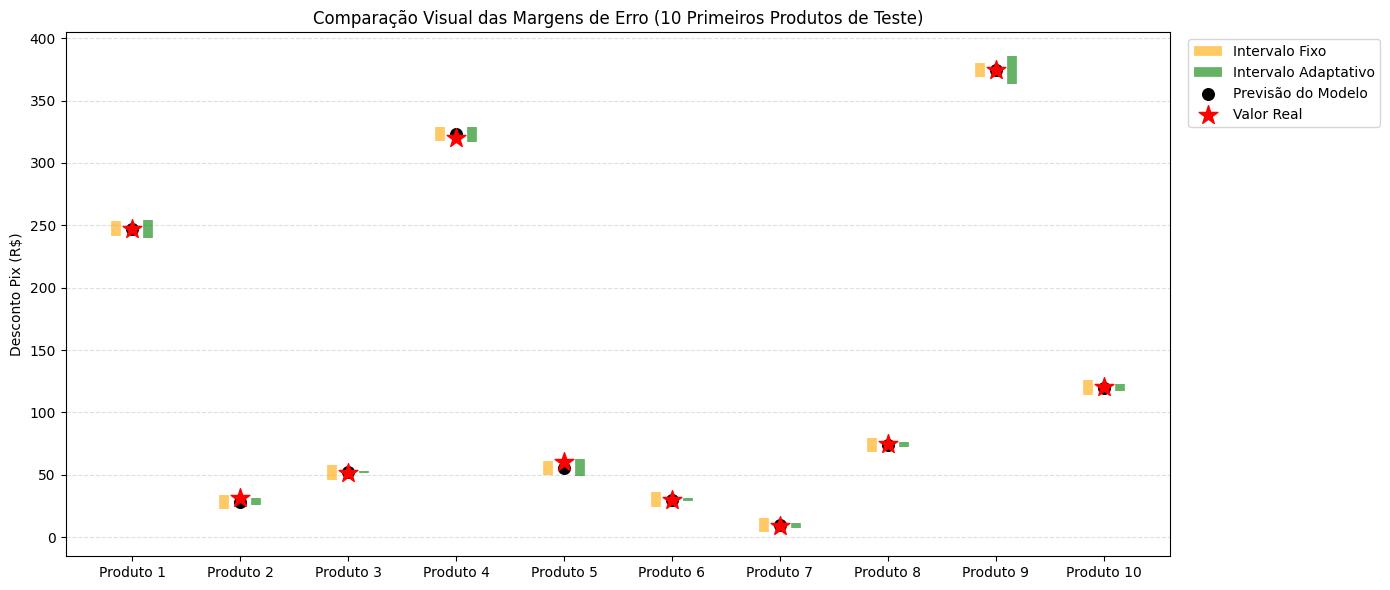

In [20]:
# Pega as 10 primeiras linhas e reseta o índice para facilitar a plotagem no eixo X
df_plot = intervalos.head(10).reset_index(drop=True)

# Eixo X representando os 10 itens
x = np.arange(len(df_plot))

# Deslocamento lateral para não sobrepor as linhas do intervalo fixo e do adaptativo
deslocamento = 0.15 

plt.figure(figsize=(14, 6))

# 1. Desenha o Intervalo Fixo (Laranja, deslocado para a esquerda)
plt.vlines(x - deslocamento, 
           ymin=df_plot['baixo_comum'], 
           ymax=df_plot['alto_comum'], 
           color='orange', linewidth=7, alpha=0.6, label='Intervalo Fixo')

# 2. Desenha o Intervalo Adaptativo (Verde, deslocado para a direita)
plt.vlines(x + deslocamento, 
           ymin=df_plot['baixo_variancia'], 
           ymax=df_plot['alto_variancia'], 
           color='green', linewidth=7, alpha=0.6, label='Intervalo Adaptativo')

# 3. Desenha a Previsão Exata do Modelo (ponto preto no centro)
# Nota: pred_comum e pred_variancia são o mesmo valor, pois a previsão pontual não muda
plt.scatter(x, df_plot['pred_comum'], 
            color='black', marker='o', s=70, zorder=4, label='Previsão do Modelo')

# 4. Desenha o Valor Real que ocorreu de fato (estrela vermelha gigante)
plt.scatter(x, df_plot['y_real'], 
            color='red', marker='*', s=200, zorder=5, label='Valor Real')

# Formatação visual do gráfico
plt.xticks(x, [f"Produto {i+1}" for i in range(10)])
plt.ylabel("Desconto Pix (R$)")
plt.title("Comparação Visual das Margens de Erro (10 Primeiros Produtos de Teste)")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left') # Joga a legenda para o lado de fora
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout() # Ajusta as margens para não cortar a legenda

plt.show()